# EDA: `products`

Разведочный анализ таблицы `products` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = ("SELECT "

                  "product_id, product_category_name_english, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm "

                  "FROM products "
                  "JOIN product_category_name_translation "
                  "USING (product_category_name)")

df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40,287,1,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44,276,1,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46,250,1,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27,261,1,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37,402,4,625.0,20.0,17.0,13.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32328 entries, 0 to 32327
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32328 non-null  str    
 1   product_category_name_english  32328 non-null  str    
 2   product_name_lenght            32328 non-null  int64  
 3   product_description_lenght     32328 non-null  int64  
 4   product_photos_qty             32328 non-null  int64  
 5   product_weight_g               32327 non-null  float64
 6   product_length_cm              32327 non-null  float64
 7   product_height_cm              32327 non-null  float64
 8   product_width_cm               32327 non-null  float64
dtypes: float64(4), int64(3), str(2)
memory usage: 2.2 MB


In [8]:
df.describe(include='all')

,product_id,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32328,32328,32328.000000,32328.000000,32328.000000,32327.000000,32327.000000,32327.000000,32327.000000
unique,32328,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,bed_bath_table,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.474078,771.520168,2.188815,2276.960807,30.856498,16.955950,23.208464
std,NaN,NaN,10.246388,635.180062,1.736746,4279.734063,16.958460,13.637246,12.080665
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,20.500000,30.000000


In [9]:
df.memory_usage(deep=True)

Index                                132
product_id                       2618568
product_category_name_english    2002411
product_name_lenght               258624
product_description_lenght        258624
product_photos_qty                258624
product_weight_g                  258624
product_length_cm                 258624
product_height_cm                 258624
product_width_cm                  258624
dtype: int64

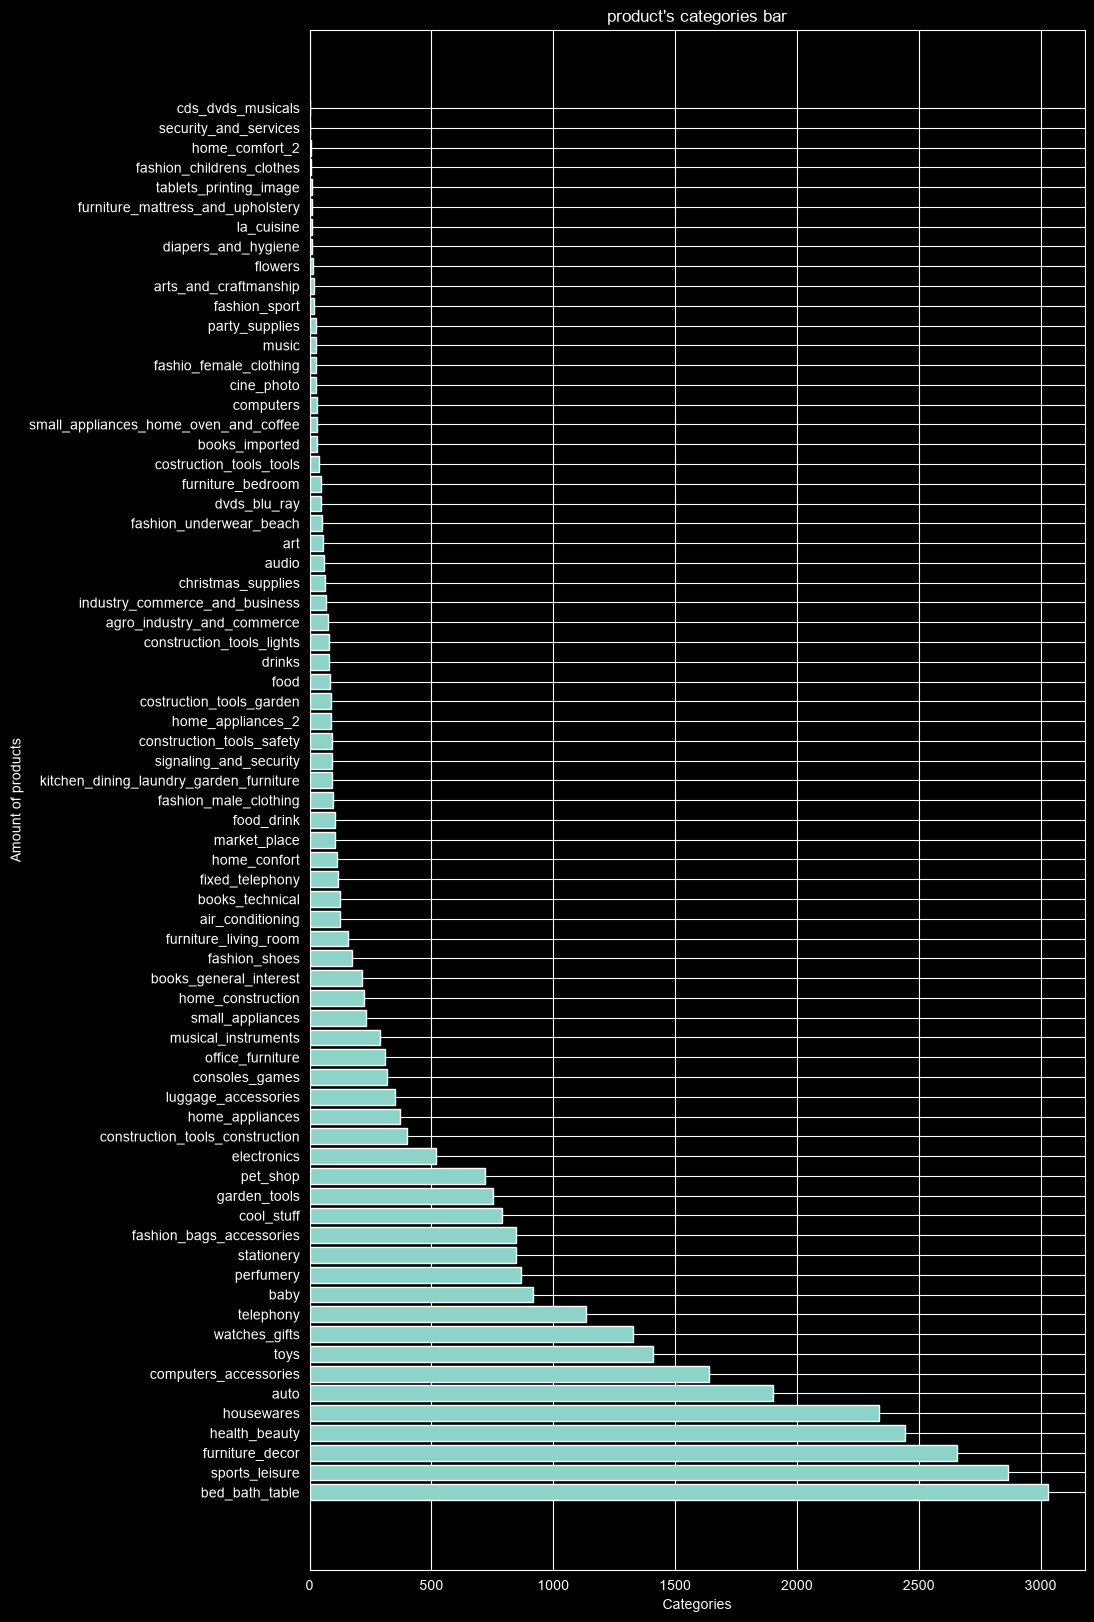

In [10]:
sampling_data = df['product_category_name_english'].value_counts()

categories = sampling_data.index
values = sampling_data.values

plt.figure(figsize=(10, 20))
plt.barh(categories, values)

plt.title("product's categories bar")
plt.xlabel('Categories')
plt.ylabel('Amount of products')

plt.show()

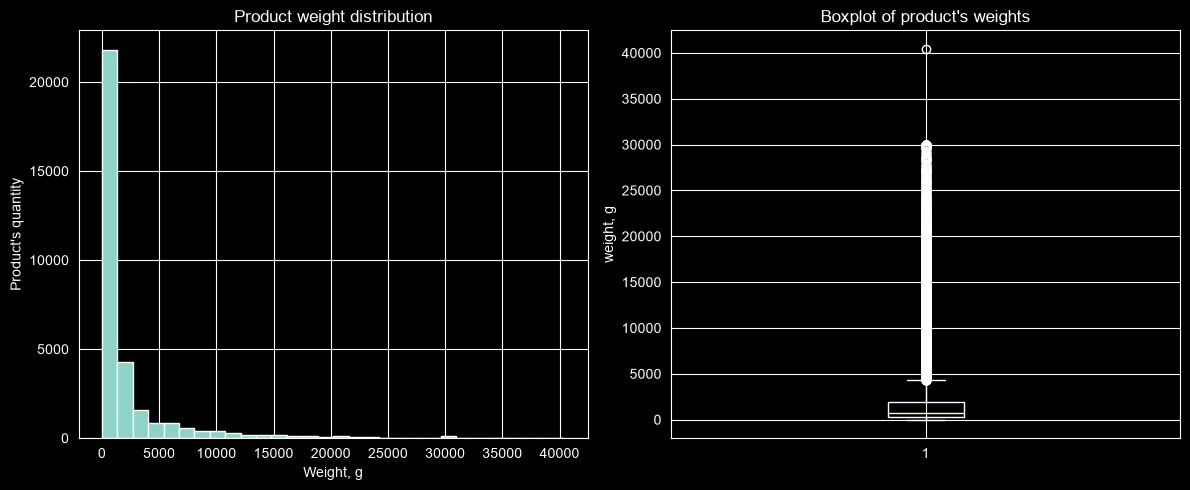

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    df["product_weight_g"].dropna(),
    bins=30
)

axes[0].set_title("Product weight distribution")
axes[0].set_xlabel("Weight, g")
axes[0].set_ylabel("Product's quantity")

axes[1].boxplot(
    df["product_weight_g"].dropna()
)

axes[1].set_title("Boxplot of product's weights")
axes[1].set_ylabel("weight, g")

plt.tight_layout()
plt.show()